In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv('house_data.csv')

In [3]:
df.head()

,Area,Bedrooms,Bathrooms,Age,Distance,Price
0,1000,2,1,10,12,45
1,1200,3,2,5,8,60
2,1500,3,2,4,6,75
3,1800,4,3,3,5,95
4,2000,4,3,2,4,110


In [4]:
# independent and dependent
X = df.drop('Price',axis=1)
y=df['Price']

In [5]:
X

,Area,Bedrooms,Bathrooms,Age,Distance
0,1000,2,1,10,12
1,1200,3,2,5,8
2,1500,3,2,4,6
3,1800,4,3,3,5
4,2000,4,3,2,4
5,2200,5,4,1,3
6,900,2,1,15,15
7,1400,3,2,7,9
8,1700,4,3,5,7
9,2500,5,4,1,2


In [6]:
y

0     45
1     60
2     75
3     95
4    110
5    130
6     38
7     68
8     88
9    150
Name: Price, dtype: int64

In [8]:
# train test and split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y, train_size=0.25, random_state=42)

In [10]:
X_train.shape, X_test.shape

((2, 5), (8, 5))

### Feature of Scaling or Standardization

In [11]:
# scaler and standscala
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
X_train=scalar.fit_transform(X_train)
X_test=scalar.transform(X_test)

### Linear Regression

mean absolute error 9.212083333333334
r2 score 0.8577660006137073


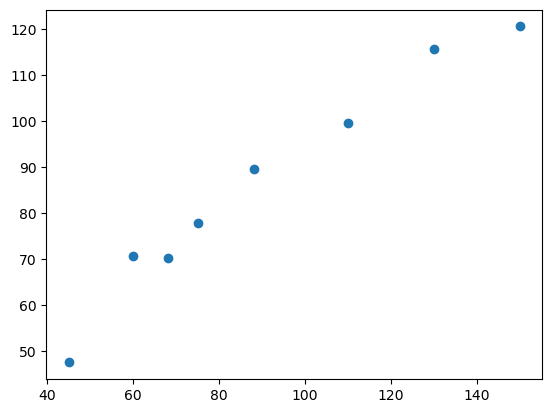

In [18]:
# linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
linreg=LinearRegression()
linreg.fit(X_train,y_train)
y_pred=linreg.predict(X_test)
mae= mean_absolute_error(y_test, y_pred)
score=r2_score(y_test, y_pred)
print('mean absolute error', mae)
print('r2 score', score)
plt.scatter(y_test,y_pred)
plt.show()


## Lasso Regression

mean_absolute_error 4.208333333333335
mean_square_error 41.578703703703724
r2_score 0.9639757806216895


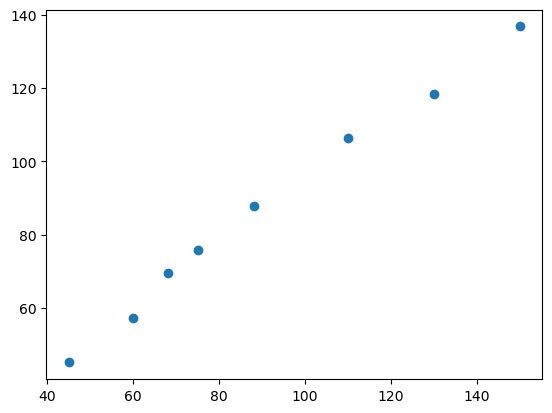

In [33]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, r2_score , mean_squared_error
lasso=Lasso(alpha=1.0)
lasso.fit(X_train,y_train)
y_lasso=lasso.predict(X_test)
mae=mean_absolute_error(y_test,y_lasso)
mse=mean_squared_error(y_test,y_lasso)
score=r2_score(y_test,y_lasso)
print('mean_absolute_error',mae)
print('mean_square_error',mse)
print('r2_score',score)
plt.scatter(y_test,y_lasso)
plt.show()


In [34]:
alphas = [0.01, 0.1, 1, 10, 100]

for alpha in alphas:
    model = Lasso(alpha=alpha)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    print(
        "Alpha:", alpha,
        "MSE:", mean_squared_error(y_test, y_lasso),
        "R2:", r2_score(y_test, y_lasso)
    )

Alpha: 0.01 MSE: 41.578703703703724 R2: 0.9639757806216895
Alpha: 0.1 MSE: 41.578703703703724 R2: 0.9639757806216895
Alpha: 1 MSE: 41.578703703703724 R2: 0.9639757806216895
Alpha: 10 MSE: 41.578703703703724 R2: 0.9639757806216895
Alpha: 100 MSE: 41.578703703703724 R2: 0.9639757806216895


In [20]:
print(lasso.coef_)

[27.5  0.   0.  -0.  -0. ]


### Ridge Regression

mean_absolute_error 10.635227272727276
r2_score 0.8005029327125252


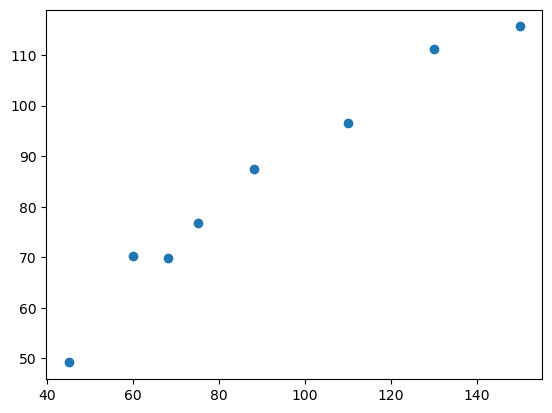

In [29]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error,r2_score
ridge=Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_ridge=ridge.predict(X_test)
mae=mean_absolute_error(y_test,y_ridge)
score=r2_score(y_test,y_ridge)
print('mean_absolute_error', mae)
print('r2_score',score)
plt.scatter(y_test,y_ridge)
plt.show()


mean_absolute_error 9.3523102310231
r2_score 0.8521799906923455


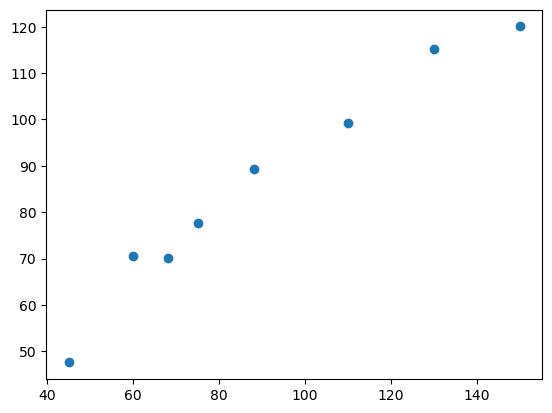

In [36]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error,r2_score
ridgedv=RidgeCV()
ridgedv.fit(X_train, y_train)
y_ridgecv=ridgedv.predict(X_test)
mae=mean_absolute_error(y_test,y_ridgecv)
score=r2_score(y_test,y_ridgecv)
print('mean_absolute_error', mae)
print('r2_score',score)
plt.scatter(y_test,y_ridgecv)
plt.show()


In [22]:
Ridge(alpha=10)

Ridge(alpha=10)

### ElasticNet Regression

mean_absolute_error 10.9537643581858
r2_score 0.7890558798468377


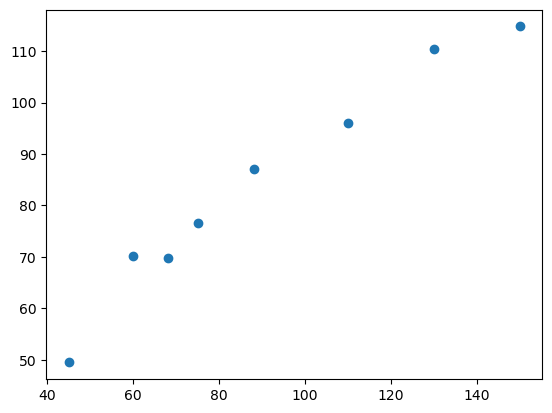

In [26]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, r2_score
elastic=ElasticNet(alpha=1.0,l1_ratio=0.5)
elastic.fit(X_train, y_train)
y_elastic= elastic.predict(X_test)
mae=mean_absolute_error(y_test,y_elastic)
score=r2_score(y_test,y_elastic)
print('mean_absolute_error',mae)
print('r2_score', score)
plt.scatter(y_test,y_elastic)
plt.show()


In [41]:
# from sklearn.linear_model import ElasticNetCV
# from sklearn.metrics import mean_absolute_error, r2_score
# elasticcv=ElasticNetCV()
# elasticcv.fit(X_train, y_train)
# y_elasticcv= elasticcv.predict(X_test)
# mae=mean_absolute_error(y_test,y_elasticcv)
# score=r2_score(y_test,y_elasticcv)
# print('mean_absolute_error',mae)
# print('r2_score', score)
# plt.scatter(y_test,y_elasticcv)
# plt.show()


##### Compare all models

In [30]:
results = pd.DataFrame({
    'models':[
        'Linear Regression',
        'Lasso',
        'Ridge',
        'ElasticNet'
    ],
    'mean':[
        mean_absolute_error(y_test,y_pred),
        mean_absolute_error(y_test,y_lasso),
        mean_absolute_error(y_test, y_ridge),
        mean_absolute_error(y_test,y_elastic)
    ],
    'r2_score':[
        r2_score(y_test,y_pred),
        r2_score(y_test,y_lasso),
        r2_score(y_test, y_ridge),
        r2_score(y_test,y_elastic)
    ]

})
print(results)

              models       mean  r2_score
0  Linear Regression  10.953764  0.789056
1              Lasso   4.208333  0.963976
2              Ridge  10.635227  0.800503
3         ElasticNet  10.953764  0.789056
